In [1]:
!pip install gymnasium
!pip install stable-baselines3[extra]
!pip install tensorboard
%load_ext tensorboard
!pip install torch --upgrade --force-reinstall

  Using cached torch-2.5.1-cp311-cp311-manylinux1_x86_64.whl.metadata (28 kB)
  Using cached filelock-3.16.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached typing_extensions-4.12.2-py3-none-any.whl.metadata (3.0 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached jinja2-3.1.5-py3-none-any.whl.metadata (2.6 kB)
  Using cached fsspec-2024.12.0-py3-none-any.whl.metadata (11 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.4.127-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.4.5.8-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.2.1.3-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Usi

# **DQN agent with simple binary rewards for storage volume constraints with smaller time steps (threshold) each episode**

Streaming output truncated to the last 5000 lines.
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 6.72     |
|    n_updates        | 560014   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 120      |
|    ep_rew_mean      | 117      |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 18672    |
|    fps              | 562      |
|    time_elapsed     | 3982     |
|    total_timesteps  | 2240640  |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 2.18     |
|    n_updates        | 560134   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 120      |
|    ep_rew_mean      | 118      |
|    exploration_rate | 0.01     |
| time/               |          |
|    episodes         | 18676    |
|   

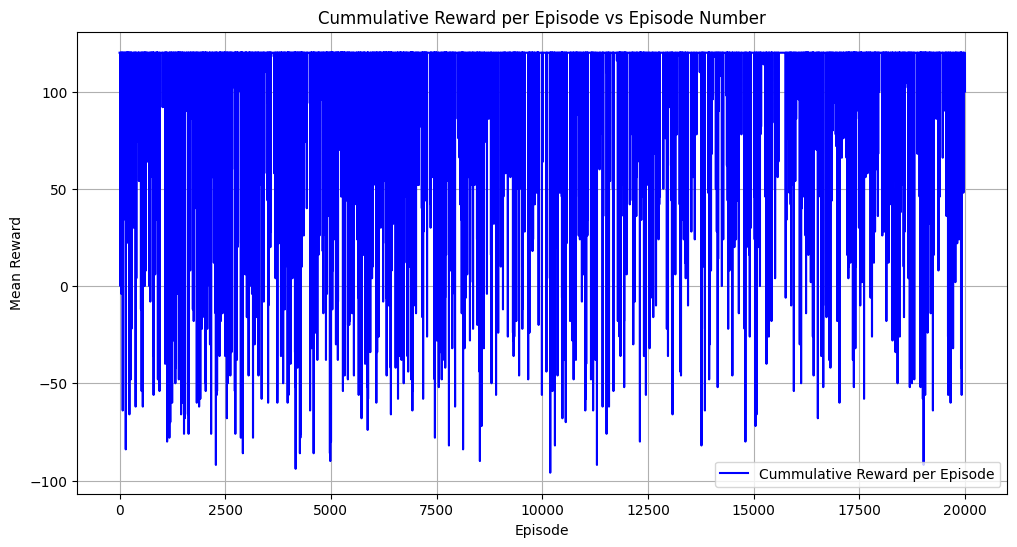

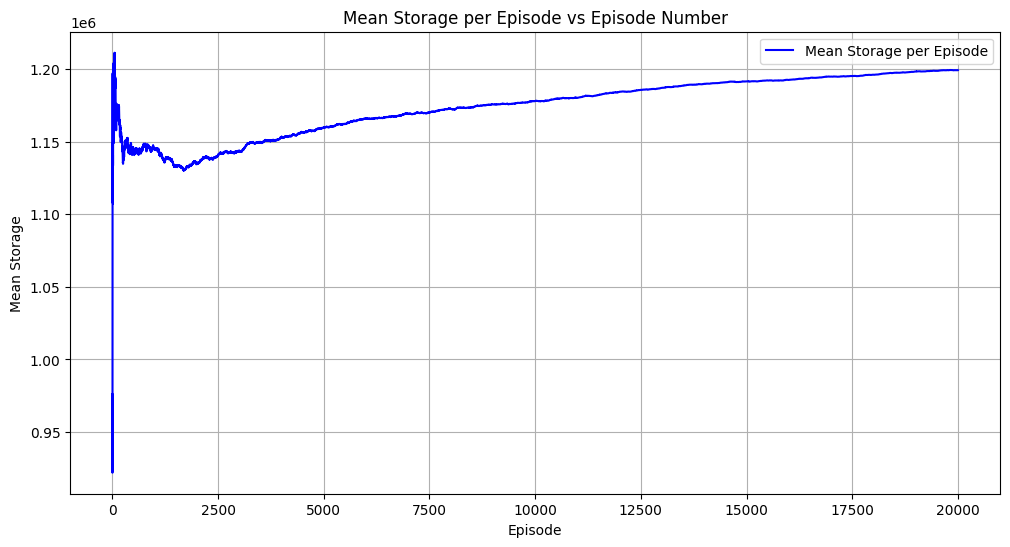

Training complete. Model and reward plot saved.


In [2]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import torch as th
import gymnasium
from gymnasium import Env
from gymnasium.spaces import Discrete, Box
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Define storage and release limits (scaled values will be calculated later)
min_storage_af = 500000
max_storage_af = 1800000
initial_storage_af = 500000
target_storage_af = (min_storage_af + max_storage_af) / 2
release_cfs_discrete = [500, 1000, 1500, 2000, 2500, 3000, 4000]  # More discrete release values
release_af = [r * 1.98211 for r in release_cfs_discrete]  # Convert cfs to acre-feet

# Load and preprocess data
data = pd.read_csv('/content/Clipped_NAVAJORESERVOIR08-18-2024T16.48.23.csv')
storage = data['Storage (af)'].values
evaporation = data['Evaporation (af)'].values
inflow_cfs = data['Inflow** (cfs)'].values
release_cfs = data['Total Release (cfs)'].values
dataset = np.column_stack((storage, evaporation, inflow_cfs * 1.98211, release_cfs * 1.98211))

# Define the custom Reservoir environment
class ReservoirEnv(Env):
    def __init__(self, dataset, release_af, min_storage_af,max_storage_af, episode_length):
        super(ReservoirEnv, self).__init__()
        self.data = dataset
        self.episode_length = episode_length
        self.release_af = release_af
        self.min_storage_af = min_storage_af
        self.max_storage_af = max_storage_af
        self.current_step = 0
        self.episode_step_count = 0
        self.reward_history=[]
        self.episode_reward=[]
        self.storage_history=[]
        self.mean_storage_history = []


        # Define action space and observation space
        self.action_space = Discrete(len(self.release_af))  # Actions: scaled release values
        self.observation_space = Box(low=0, high=1, shape=(3,), dtype=np.float32)

    def reset(self, seed=None):
        self.current_step = np.random.randint(0, len(self.data) - self.episode_length)
        self.episode_step_count = 0
        self.reward_history.clear()

        # Set the storage to the scaled value corresponding to the start of the episode
        self.current_storage = self.data[self.current_step, 0]
        return self._get_observation(), {}

    def _get_observation(self):
        return np.array([self.current_storage, self.data[self.current_step, 1], self.data[self.current_step, 2]])

    def step(self, action):
        # Mapping action index to scaled release value
        release_af_value = self.release_af[action]
        inflow_af = self.data[self.current_step, 2]
        evaporation_af = self.data[self.current_step, 1]

        # Updating storage with inflow, evaporation, and release (all in scaled values)
        self.current_storage += inflow_af - evaporation_af - release_af_value
        # print(f"Step {self.current_step}: Actual Storage: {self.data[self.current_step, 0]}, Current Storage: {self.current_storage}, Actual Release: {self.data[self.current_step, 3]}, Predicted Release: {release_af_value}")

        # Reward calculation (scaled storage range: 0 to 1)
        if self.min_storage_af<= self.current_storage <= self.max_storage_af:
            reward = 1 # Positive reward for staying within bounds
            # reward = 1- (abs(self.current_storage - target_storage_af) / target_storage_af)  # Positive reward for staying within bounds
        else:
            reward = -1  # Negative reward for going out of bounds

        self.reward_history.append(reward)
        self.storage_history.append(self.current_storage)
        self.current_step += 1
        self.episode_step_count += 1
        done = self.current_step >= len(self.data) or (self.episode_step_count % self.episode_length == 0)

        # Recording mean rewards after each episode
        if done:
            cum_reward = sum(self.reward_history)
            self.episode_reward.append(cum_reward)
            self.mean_storage_history.append(np.mean(self.storage_history))

        observation = self._get_observation() if not done else np.zeros(3)
        return observation, reward, done, False, {}

    def render(self, mode='human', close=False):
        pass

# Set up environment
episode_length = 120
env = ReservoirEnv(dataset, release_af, min_storage_af,max_storage_af, episode_length)

# Initialize DQN model
model = DQN(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=1e-3,
    batch_size=32,
    train_freq=4,
    buffer_size=100000,
    exploration_fraction=0.3,
    exploration_final_eps=0.01,
    target_update_interval=1000,
)

# Training the model
n_episodes = 20000
total_timesteps = n_episodes * episode_length
model.learn(total_timesteps=total_timesteps)

# Save the model
model.save("dqn_reservoir_agent")

# Plot mean rewards per episode
plt.figure(figsize=(12, 6))
plt.plot(env.episode_reward, label="Cummulative Reward per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Reward")
plt.title("Cummulative Reward per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("cummulative_rewards_per_episode.png")
plt.show()

# Plot mean storage per episode
plt.figure(figsize=(12, 6))
plt.plot(env.mean_storage_history, label="Mean Storage per Episode", color="blue")
plt.xlabel("Episode")
plt.ylabel("Mean Storage")
plt.title("Mean Storage per Episode vs Episode Number")
plt.grid()
plt.legend()
plt.savefig("mean_storage_per_episode.png")
plt.show()

print("Training complete. Model and reward plot saved.")

506159.0
Prediction completed and saved to CSV files.


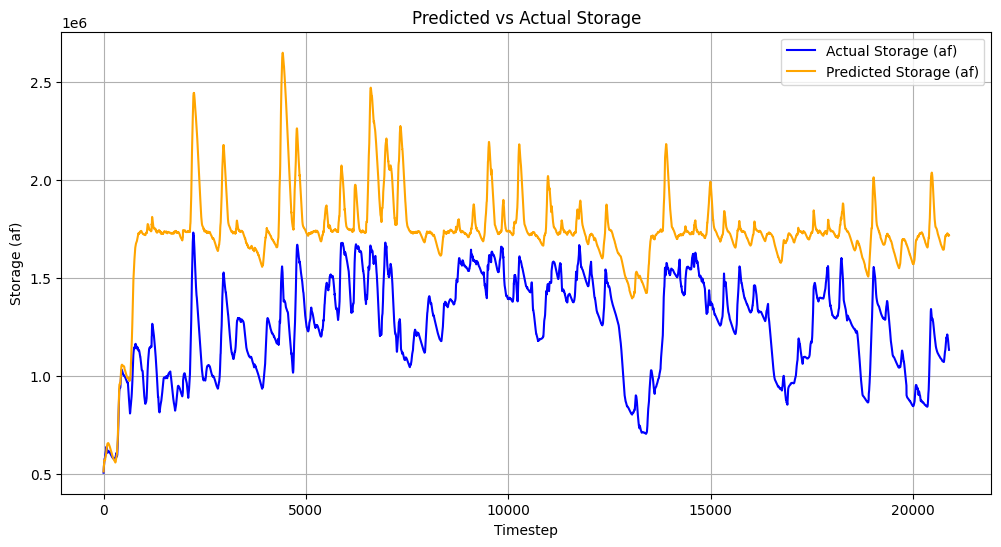

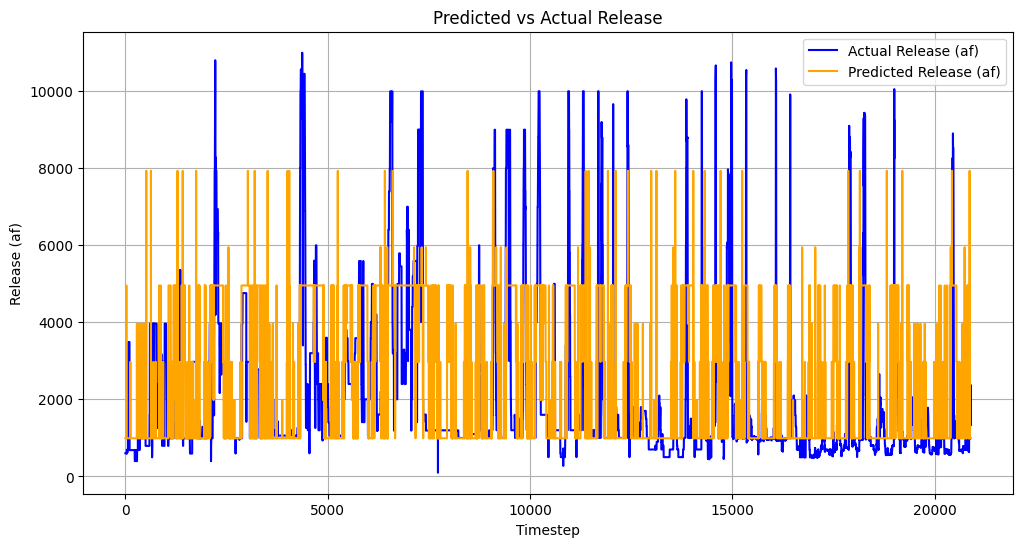

In [4]:
# Load the trained DQN agent
model = DQN.load("dqn_reservoir_agent")

# Set up variables for predictions
predicted_storage = []
actual_storage = []
predicted_release = []
actual_release = []

# Initialize current storage
current_storage = dataset[0,0]
print(current_storage)

# Perform predictions
for i in range(len(dataset)):
    # Get the observation from the dataset (without scaling)
    observation = np.array([current_storage, dataset[i, 1], dataset[i, 2]])
    # Predict the action using the trained agent
    action, _ = model.predict(observation)

    # Map the action to the corresponding release value in acre-feet
    predicted_release_af = release_af[action]

    # Extract inflow and evaporation directly from the dataset (unscaled)
    inflow_af = dataset[i, 2]
    evaporation_af = dataset[i, 1]

    # Update the current storage using the predicted release, inflow, and evaporation
    current_storage += inflow_af - evaporation_af - predicted_release_af

    # Store results for analysis
    predicted_storage.append(current_storage)
    predicted_release.append(predicted_release_af)
    actual_storage.append(dataset[i, 0])  # Actual storage from the dataset
    actual_release.append(dataset[i, 3])  # Actual release from the dataset
    # print(f"Step {i}: Observation: {observation}, Predicted Release: {predicted_release_af}, Current Storage: {current_storage}")


# Save results to CSV files
predicted_vs_actual_storage = pd.DataFrame({
    "Predicted Storage (af)": predicted_storage,
    "Actual Storage (af)": actual_storage
})
predicted_vs_actual_release = pd.DataFrame({
    "Predicted Release (af)": predicted_release,
    "Actual Release (af)": actual_release
})

# Save the results to CSV files
predicted_vs_actual_storage.to_csv("predicted_vs_actual_storage_complete_data.csv", index=False)
predicted_vs_actual_release.to_csv("predicted_vs_actual_release_complete_data.csv", index=False)
pd.DataFrame(dataset).to_csv("complete_dataset.csv", index=False)

print("Prediction completed and saved to CSV files.")

# Plot Predicted vs Actual Storage
plt.figure(figsize=(12, 6))
plt.plot(actual_storage, label="Actual Storage (af)", color="blue")
plt.plot(predicted_storage, label="Predicted Storage (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Storage (af)")
plt.title("Predicted vs Actual Storage")
plt.legend()
plt.grid()
plt.show()

# Plot Predicted vs Actual Release
plt.figure(figsize=(12, 6))
plt.plot(actual_release, label="Actual Release (af)", color="blue")
plt.plot(predicted_release, label="Predicted Release (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Release (af)")
plt.title("Predicted vs Actual Release")
plt.legend()
plt.grid()
plt.show()